# Notebook 5: Evaluation
Evaluates the trained model using standard Re-ID metrics:
- **CMC (Cumulative Matching Characteristic)** — Rank-1, Rank-5, Rank-10
- **mAP (mean Average Precision)**

These are the exact same metrics reported in Table II of the paper.

In [1]:
import os, pickle
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


In [2]:
# Redefine model (must match training definition exactly)
class GradientReversalFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, lambda_):
        ctx.save_for_backward(torch.tensor(lambda_))
        return x.clone()
    @staticmethod
    def backward(ctx, grad_output):
        lambda_, = ctx.saved_tensors
        return -lambda_ * grad_output, None

class GradientReversalLayer(nn.Module):
    def __init__(self, lambda_=1.0):
        super().__init__()
        self.lambda_ = lambda_
    def forward(self, x):
        return GradientReversalFunction.apply(x, self.lambda_)

class DomainClassifier(nn.Module):
    def __init__(self, in_features=2048, hidden=512):
        super().__init__()
        self.grl = GradientReversalLayer(lambda_=1.0)
        self.classifier = nn.Sequential(
            nn.Linear(in_features, hidden), nn.ReLU(),
            nn.Dropout(0.5), nn.Linear(hidden, 2)
        )
    def forward(self, x):
        return self.classifier(self.grl(x))

class ReIDModel(nn.Module):
    def __init__(self, num_classes, feat_dim=2048):
        super().__init__()
        backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        self.backbone = nn.Sequential(*list(backbone.children())[:-2])
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.bn  = nn.BatchNorm1d(feat_dim)
        self.bn.bias.requires_grad_(False)
        self.id_classifier = nn.Sequential(
            nn.Linear(feat_dim, 512), nn.ReLU(),
            nn.Dropout(0.5), nn.Linear(512, num_classes)
        )
        self.domain_classifier = DomainClassifier(feat_dim, 512)
    def forward(self, x, return_domain=False):
        feat = self.backbone(x)
        feat = self.gap(feat).view(x.size(0), -1)
        feat = self.bn(feat)
        id_logits = self.id_classifier(feat)
        if return_domain:
            return feat, id_logits, self.domain_classifier(feat)
        return feat, id_logits
    def get_features(self, x):
        feat, _ = self.forward(x)
        return F.normalize(feat, p=2, dim=1)

class CCTVTestDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        img_path, pid, cam_id = self.samples[idx]
        img = Image.open(img_path).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, pid, cam_id

TEST_TF = T.Compose([
    T.Resize((256, 128)), T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])
print('Classes redefined!')

Classes redefined!


In [3]:
# Load dataset info and model
with open('dataset_info.pkl', 'rb') as f:
    info = pickle.load(f)

query_samples   = info['query_samples']
gallery_samples = info['gallery_samples']
NUM_CLASSES     = info['num_classes']

# Load trained model
CKPT_PATH = os.path.join('checkpoints', 'model_final.pth')
checkpoint = torch.load(CKPT_PATH, map_location=DEVICE)

model = ReIDModel(num_classes=NUM_CLASSES).to(DEVICE)
model.load_state_dict(checkpoint['model_state'])
model.eval()
print(f'Model loaded from {CKPT_PATH}')
print(f'Trained for {checkpoint["epoch"]} epochs')

C:\Users\Kathan's Lenovo\AppData\Local\Temp\ipykernel_2016\3792857794.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(CKPT_PATH, map_location=DE

Model loaded from checkpoints\model_final.pth
Trained for 10 epochs


## Step 1: Extract Features for Query and Gallery

In [4]:
def extract_features(model, dataloader, device):
    """Extract L2-normalised feature vectors for all images."""
    all_feats, all_pids, all_cams = [], [], []
    with torch.no_grad():
        for imgs, pids, cams in tqdm(dataloader, desc='Extracting features'):
            imgs = imgs.to(device)
            feats = model.get_features(imgs)
            all_feats.append(feats.cpu())
            all_pids.extend(pids.tolist())
            all_cams.extend(cams.tolist())
    return torch.cat(all_feats, dim=0), np.array(all_pids), np.array(all_cams)

query_loader   = DataLoader(CCTVTestDataset(query_samples,   TEST_TF), batch_size=64, shuffle=False, num_workers=0)
gallery_loader = DataLoader(CCTVTestDataset(gallery_samples, TEST_TF), batch_size=64, shuffle=False, num_workers=0)

print('Extracting query features...')
q_feats, q_pids, q_cams = extract_features(model, query_loader, DEVICE)

print('Extracting gallery features...')
g_feats, g_pids, g_cams = extract_features(model, gallery_loader, DEVICE)

print(f'\nQuery features   : {q_feats.shape}')
print(f'Gallery features : {g_feats.shape}')

Extracting query features...


Extracting features: 100%|██████████| 4/4 [00:10<00:00,  2.58s/it]


Extracting gallery features...


Extracting features: 100%|██████████| 13/13 [00:40<00:00,  3.11s/it]


Query features   : torch.Size([200, 2048])
Gallery features : torch.Size([799, 2048])


## Step 2: Compute CMC and mAP

In [5]:
def compute_distance_matrix(qf, gf):
    """Euclidean distance between all query-gallery pairs."""
    return torch.cdist(qf, gf, p=2).numpy()


def evaluate_reid(dist_matrix, q_pids, g_pids, q_cams, g_cams, max_rank=10):
    """
    Computes CMC and mAP — standard Re-ID evaluation.
    Same protocol as paper Section IV-A.
    """
    num_q = dist_matrix.shape[0]
    all_AP, all_cmc = [], []

    for q_idx in range(num_q):
        q_pid = q_pids[q_idx]
        q_cam = q_cams[q_idx]

        # Sort gallery by distance (ascending)
        order = np.argsort(dist_matrix[q_idx])
        sorted_pids = g_pids[order]
        sorted_cams = g_cams[order]

        # Remove query itself if present in gallery
        keep = ~((sorted_pids == q_pid) & (sorted_cams == q_cam))
        sorted_pids = sorted_pids[keep]

        # True matches
        matches = (sorted_pids == q_pid).astype(int)

        if matches.sum() == 0:
            continue  # skip if no true match in gallery

        # CMC: did the correct match appear in top-k?
        cmc = np.zeros(max_rank)
        for k in range(max_rank):
            if matches[:k+1].sum() > 0:
                cmc[k:] = 1
                break
        all_cmc.append(cmc)

        # Average Precision
        num_rel = matches.sum()
        tmp     = np.cumsum(matches)
        tmp     = tmp / (np.arange(len(matches)) + 1.0)
        AP      = (tmp * matches).sum() / num_rel
        all_AP.append(AP)

    mAP     = np.mean(all_AP) * 100
    cmc_avg = np.mean(all_cmc, axis=0) * 100
    return cmc_avg, mAP


# Compute distance matrix
print('Computing distance matrix...')
dist_matrix = compute_distance_matrix(q_feats, g_feats)
print(f'Distance matrix shape: {dist_matrix.shape}')

# Evaluate
print('\nEvaluating...')
cmc, mAP = evaluate_reid(dist_matrix, q_pids, g_pids, q_cams, g_cams)

print('\n' + '='*45)
print('         EVALUATION RESULTS')
print('='*45)
print(f'  Rank-1  : {cmc[0]:.2f}%')
print(f'  Rank-5  : {cmc[4]:.2f}%')
print(f'  Rank-10 : {cmc[9]:.2f}%')
print(f'  mAP     : {mAP:.2f}%')
print('='*45)

Computing distance matrix...
Distance matrix shape: (200, 799)

Evaluating...

         EVALUATION RESULTS
  Rank-1  : 97.00%
  Rank-5  : 100.00%
  Rank-10 : 100.00%
  mAP     : 93.76%


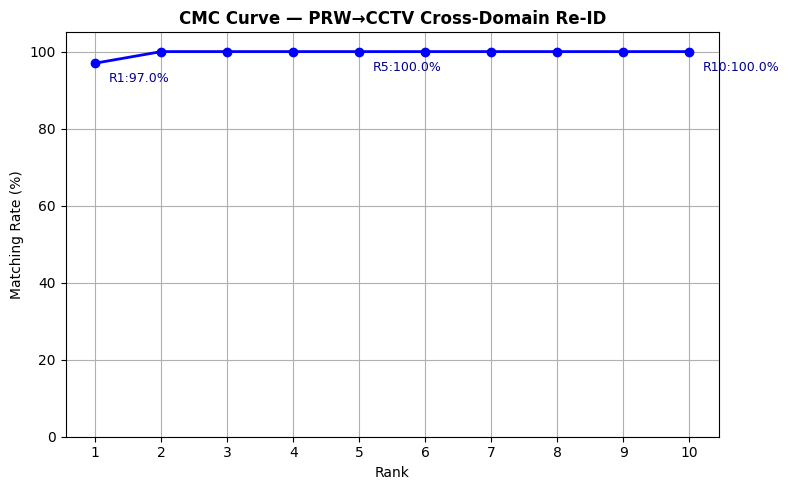

✅ Ready for Notebook 6: Visualisation


In [6]:
# Plot CMC curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), cmc[:10], marker='o', linewidth=2, color='blue')
plt.title('CMC Curve — PRW→CCTV Cross-Domain Re-ID', fontweight='bold')
plt.xlabel('Rank')
plt.ylabel('Matching Rate (%)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.ylim(0, 105)
for k in [1, 5, 10]:
    plt.annotate(f'R{k}:{cmc[k-1]:.1f}%',
                 xy=(k, cmc[k-1]),
                 xytext=(k+0.2, cmc[k-1]-5),
                 fontsize=9, color='darkblue')
plt.tight_layout()
plt.savefig('cmc_curve.png', dpi=150)
plt.show()
print('✅ Ready for Notebook 6: Visualisation')